# 第061讲 可复现实验
先阅读lab.pdf。所有输出来自本目录固定数据；运行不会覆盖冻结结果。

In [1]:
from pathlib import Path
import json
import numpy as np
from common import load_data
data = load_data()
print({k: len(v["id"]) for k,v in data.items()})

{'train': 180, 'validation': 120, 'test': 240}


## 六行两轮手算核验
标签为-1/+1，分数不是概率。

In [2]:
from adaboost import AdaBoost
X = np.arange(1,7).reshape(-1,1)
y = np.array([-1,-1,1,-1,1,1])
model = AdaBoost(2).fit(X,y)
for h in model.history_:
    print({k:h[k] for k in ["round","error","alpha","weights_after","exp_loss"]})
print("scores",model.decision_function(X))

{'round': 1, 'error': 0.16666666666666669, 'alpha': 0.8047189562170501, 'weights_after': [0.09999999999999998, 0.09999999999999998, 0.09999999999999998, 0.5, 0.09999999999999998, 0.09999999999999998], 'exp_loss': 0.7453559924999299}
{'round': 2, 'error': 0.09999999999999998, 'alpha': 1.0986122886681098, 'weights_after': [0.05555555555555554, 0.05555555555555554, 0.5000000000000001, 0.27777777777777785, 0.05555555555555554, 0.05555555555555554], 'exp_loss': 0.4472135954999579}
scores [-1.90333124 -1.90333124 -0.29389333 -0.29389333  1.90333124  1.90333124]


## 冻结配置的完整实验
测试集只用于报告，配置不会根据测试结果改变。

In [3]:
from experiment import run
report = run()
print(json.dumps({k:v["metrics"] for k,v in report["results"].items()},ensure_ascii=False,indent=2))

{
  "clean": {
    "train": {
      "from_zero_accuracy": 1.0,
      "sklearn_accuracy": 1.0,
      "prediction_agreement": 1.0
    },
    "validation": {
      "from_zero_accuracy": 1.0,
      "sklearn_accuracy": 1.0,
      "prediction_agreement": 1.0
    },
    "test": {
      "from_zero_accuracy": 0.9791666666666666,
      "sklearn_accuracy": 0.9833333333333333,
      "prediction_agreement": 0.9958333333333333
    }
  },
  "noisy": {
    "train": {
      "from_zero_accuracy": 0.8888888888888888,
      "sklearn_accuracy": 0.8833333333333333,
      "prediction_agreement": 0.9611111111111111
    },
    "validation": {
      "from_zero_accuracy": 0.9166666666666666,
      "sklearn_accuracy": 0.9416666666666667,
      "prediction_agreement": 0.925
    },
    "test": {
      "from_zero_accuracy": 0.9166666666666666,
      "sklearn_accuracy": 0.9291666666666667,
      "prediction_agreement": 0.9458333333333333
    }
  }
}


In [4]:
for mode in ["clean","noisy"]:
    r=report["results"][mode]
    print(mode,"flip mass",r["flipped_weight_mass"][-1],"effective n",r["effective_sample_size"][-1])

clean flip mass 0.027372161242535824 effective n 28.32254114151895
noisy flip mass 0.369260488418939 effective n 76.34426084333404


In [5]:
import subprocess,sys
command=[sys.executable,"test_experiment.py","--out","outputs/notebook-tests.json"]
completed=subprocess.run(command,check=True,capture_output=True,text=True)
result=json.loads(completed.stdout)
print(result["status"],result["check_count"])

passed 55


## 图的阅读
图为同一冻结实验生成；图题与解释见lecture.pdf和lab.pdf。

01_margin_loss.png


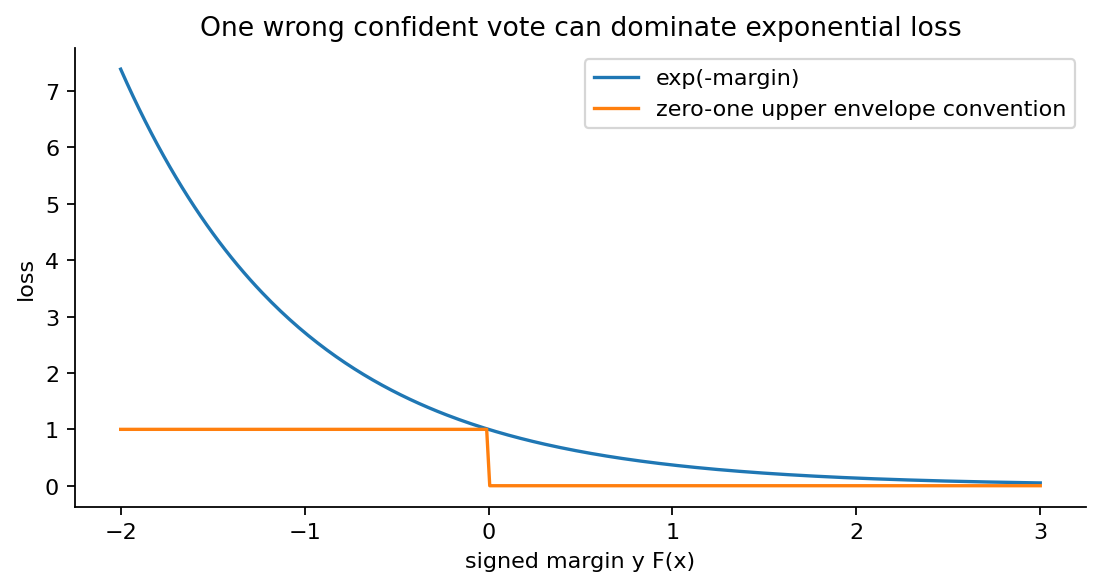

02_two_round_weights.png


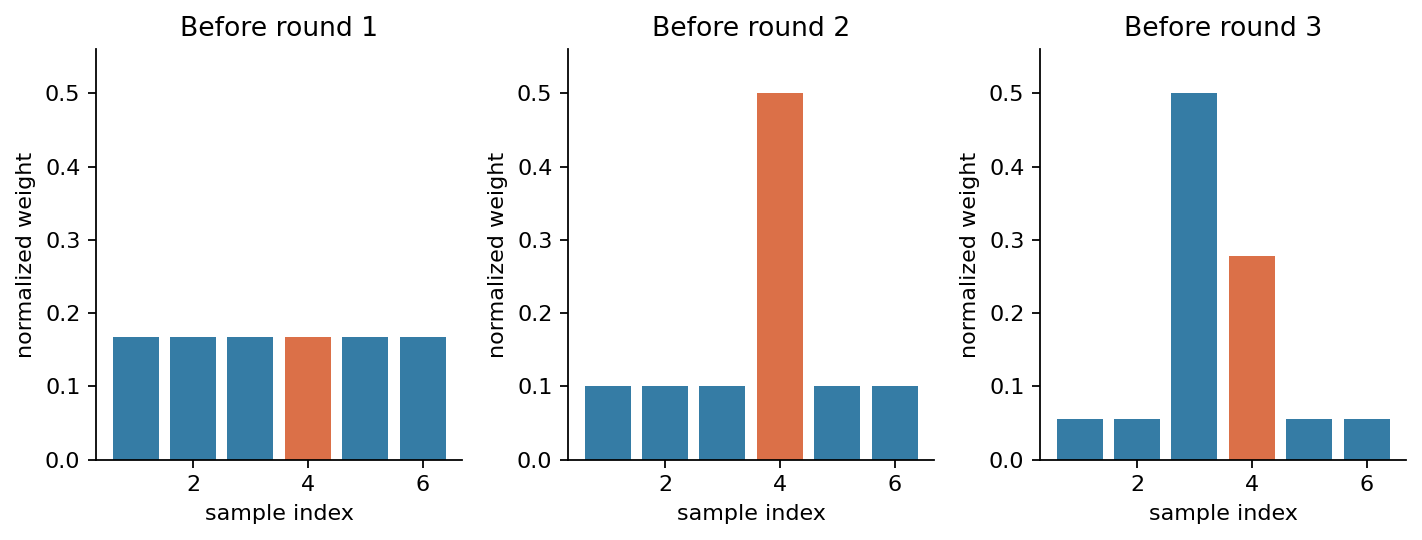

03_learning_curves.png


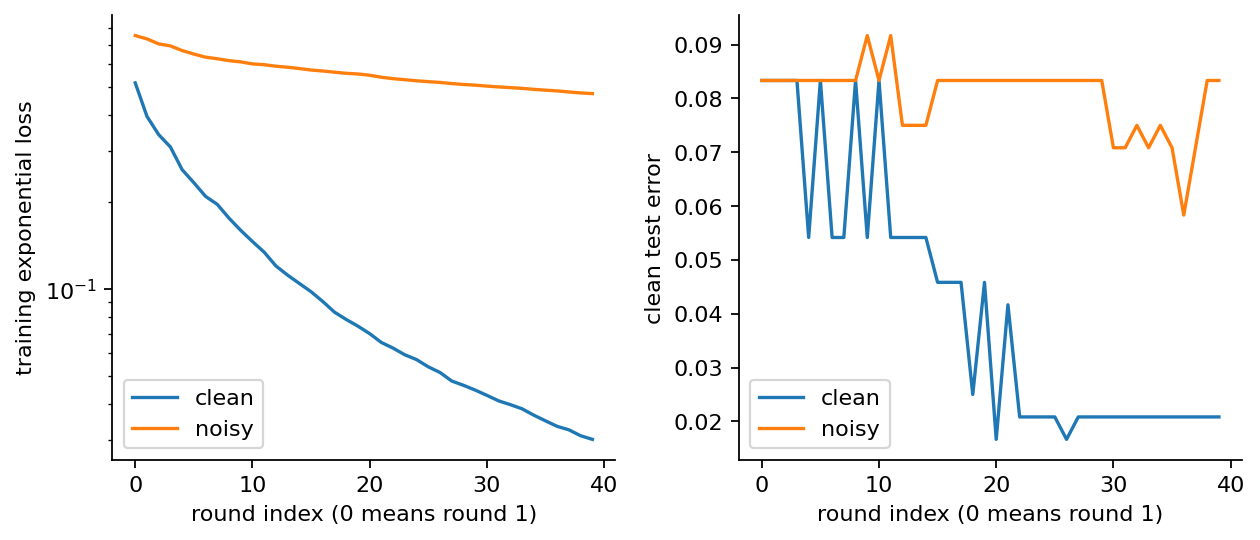

04_noise_concentration.png


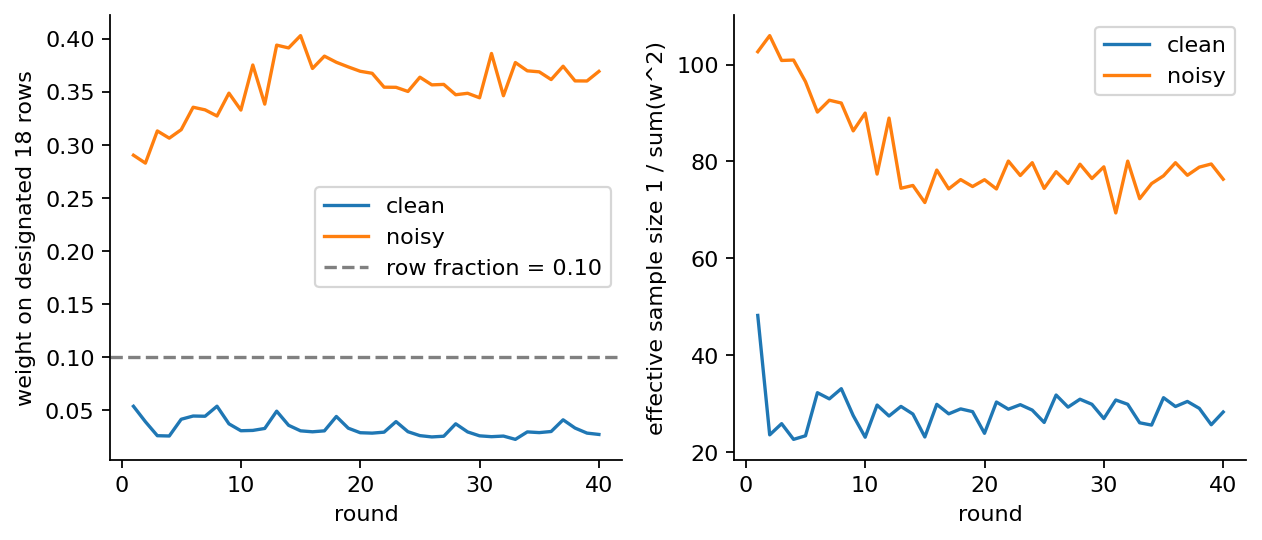

05_boundaries.png


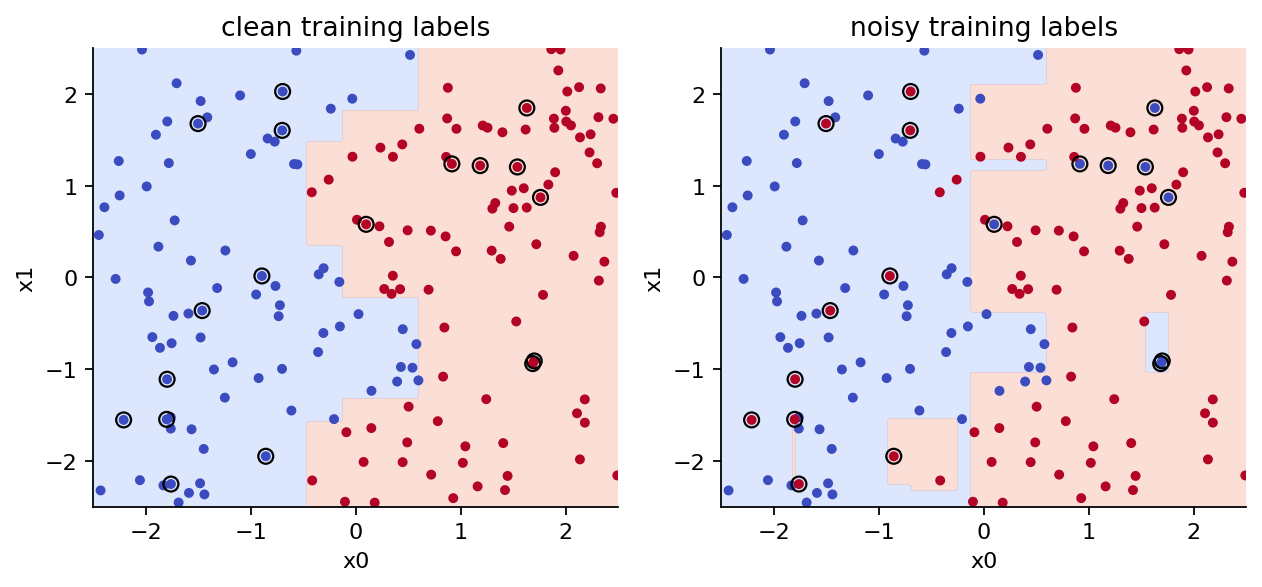

06_margin_distribution.png


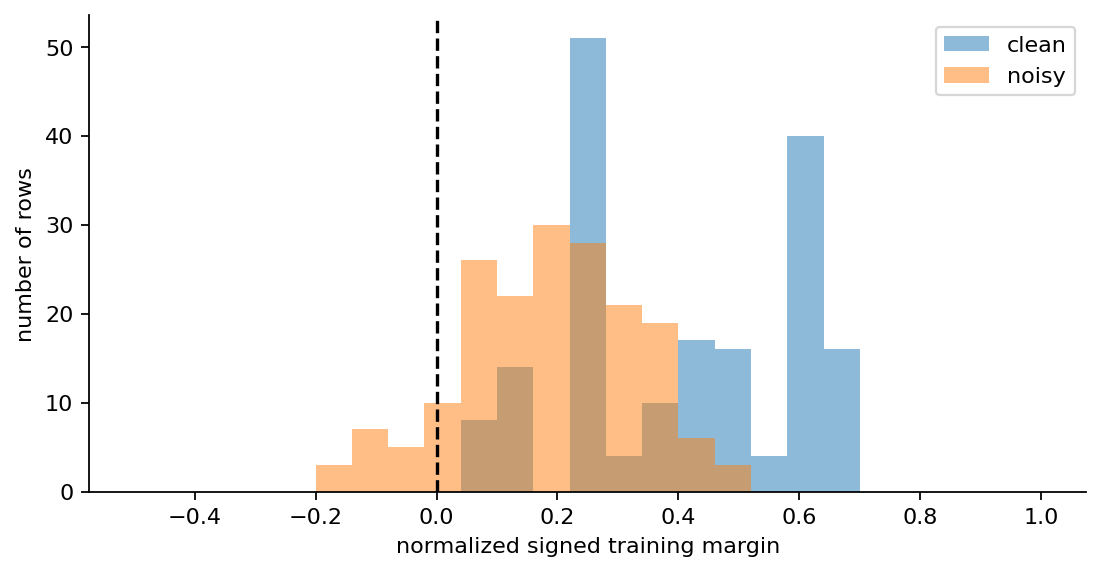

In [6]:
from IPython.display import display,Image
for name in sorted(Path("figures").glob("*.png")):
    print(name.name)
    display(Image(filename=str(name),width=650))